In [1]:
 !pip install tensorflow mtcnn opencv-python scikit-learn matplotlib seaborn imbalanced-learn joblib

In [27]:
from pathlib import Path

# ── EDIT THESE ─────────────────────────────────────────────────────────────
DATASET_ROOT   = Path(r'C:\Users\gauri\OneDrive\Desktop\driver drowsiness detection\driver-drowsiness-detection\Dataset')  # root with sub1 sub2 sub3
OUTPUT_DIR     = Path('./cnn_output')               # where models & plots are saved
GBM_MODEL_PATH = Path('./model.pkl')               # your existing GBM model
# ────────────────────────────────────────────────────────────────────────────

IMG_SIZE      = (224, 224)   # MobileNetV2 input size
BATCH_SIZE    = 32
EPOCHS_FROZEN = 10           # phase 1: only train the head
EPOCHS_FINE   = 15           # phase 2: fine-tune top layers of base model
LEARNING_RATE = 1e-4
FINE_LR       = 1e-5
SEED          = 42
TEST_SPLIT    = 0.20
VAL_SPLIT     = 0.10
USE_FACE_CROP = True         # set False if MTCNN is slow on your machine

# Folder name → integer label
LABEL_MAP = {
    'eyeclose': 1,
    'yawn': 1,
    'neutral': 0,
    'happy': 0
}
CLASS_NAMES = ['alert', 'drowsy']

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Config OK. Dataset root:', DATASET_ROOT)
print('Output dir:', OUTPUT_DIR)

Config OK. Dataset root: C:\Users\gauri\OneDrive\Desktop\driver drowsiness detection\driver-drowsiness-detection\Dataset
Output dir: cnn_output


In [28]:
import os, json, warnings, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, f1_score
)
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings('ignore')
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs available:', gpus if gpus else 'None — using CPU')

TensorFlow version: 2.21.0
GPUs available: None — using CPU


In [30]:
if USE_FACE_CROP:
    from mtcnn import MTCNN
    face_detector = MTCNN()
    print('MTCNN face detector loaded.')
else:
    face_detector = None
    print('Face cropping disabled.')


def crop_face(img_bgr, margin=0.25):
    """
    Detect largest face and return cropped RGB image (224x224).
    Falls back to full image if detection fails.
    """

    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # If cropping disabled
    if face_detector is None:
        return cv2.resize(rgb, IMG_SIZE)

    results = face_detector.detect_faces(rgb)

    # No face detected → fallback
    if not results:
        return cv2.resize(rgb, IMG_SIZE)

    # Take best face (highest confidence)
    best = max(results, key=lambda r: r['confidence'])

    # ❗ Ignore weak detections
    if best['confidence'] < 0.90:
        return cv2.resize(rgb, IMG_SIZE)

    x, y, w, h = best['box']
    h_img, w_img = rgb.shape[:2]

    # ❗ Fix negative values
    x = max(0, x)
    y = max(0, y)

    # Add margin
    mx = int(w * margin)
    my = int(h * margin)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(w_img, x + w + mx)
    y2 = min(h_img, y + h + my)

    face_crop = rgb[y1:y2, x1:x2]

    # ❗ Safety fallback
    if face_crop is None or face_crop.size == 0:
        return cv2.resize(rgb, IMG_SIZE)

    return cv2.resize(face_crop, IMG_SIZE)

MTCNN face detector loaded.


In [31]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

def load_dataset(dataset_root: Path):

    images, labels, paths = [], [], []
    total_skipped = 0
    no_face_count = 0

    for subject_dir in sorted(dataset_root.iterdir()):
        if not subject_dir.is_dir():
            continue

        for label_dir in sorted(subject_dir.iterdir()):
            if not label_dir.is_dir():
                continue

            key = label_dir.name.lower().replace(' ', '_').replace('-', '_')

            if key not in LABEL_MAP:
                print(f'  [SKIP] unknown folder: {label_dir.name}')
                continue

            label_int = LABEL_MAP[key]

            img_files = [f for f in label_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]

            print(f'  [{label_dir.name} → {label_int}]  {len(img_files)} images')

            for img_path in img_files:

                # ── read image ─────────────────────────────
                bgr = cv2.imread(str(img_path))
                if bgr is None:
                    total_skipped += 1
                    continue

                try:
                    # ── Step 1: face crop ─────────────────
                    if USE_FACE_CROP:
                        face = crop_face(bgr)
                        if face is None:
                            no_face_count += 1
                            continue
                    else:
                        face = cv2.resize(bgr, IMG_SIZE)

                    # ── Step 2: resize (IMPORTANT) ────────
                    face = cv2.resize(face, IMG_SIZE)

                    # ── Step 3: convert BGR → RGB ─────────
                    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

                    # ── Step 4: normalize ────────────────
                    face = face.astype(np.float32) / 255.0

                    images.append(face)
                    labels.append(label_int)
                    paths.append(str(img_path))

                except Exception as e:
                    total_skipped += 1
                    continue

    print(f'\nTotal loaded: {len(images)}')
    print(f'Skipped (bad images): {total_skipped}')
    print(f'Skipped (no face): {no_face_count}')

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32), paths


# ── RUN ─────────────────────────────────────────────
print('Loading dataset — this may take a few minutes...')
t0 = time.time()

X_all, y_all, file_paths = load_dataset(DATASET_ROOT)

print(f'Done in {time.time()-t0:.1f}s')
print('Class distribution:', Counter(y_all))
print('Shape:', X_all.shape)

Loading dataset — this may take a few minutes...
  [Eyeclose → 1]  157 images
  [Neutral → 0]  166 images
  [Yawn → 1]  58 images
  [Eyeclose → 1]  316 images
  [Happy → 0]  76 images
  [Neutral → 0]  167 images
  [Yawn → 1]  51 images
  [Eyeclose → 1]  145 images
  [Happy → 0]  35 images
  [Neutral → 0]  88 images
  [Yawn → 1]  60 images

Total loaded: 1319
Skipped (bad images): 0
Skipped (no face): 0
Done in 1535.8s
Class distribution: Counter({np.int32(1): 787, np.int32(0): 532})
Shape: (1319, 224, 224, 3)


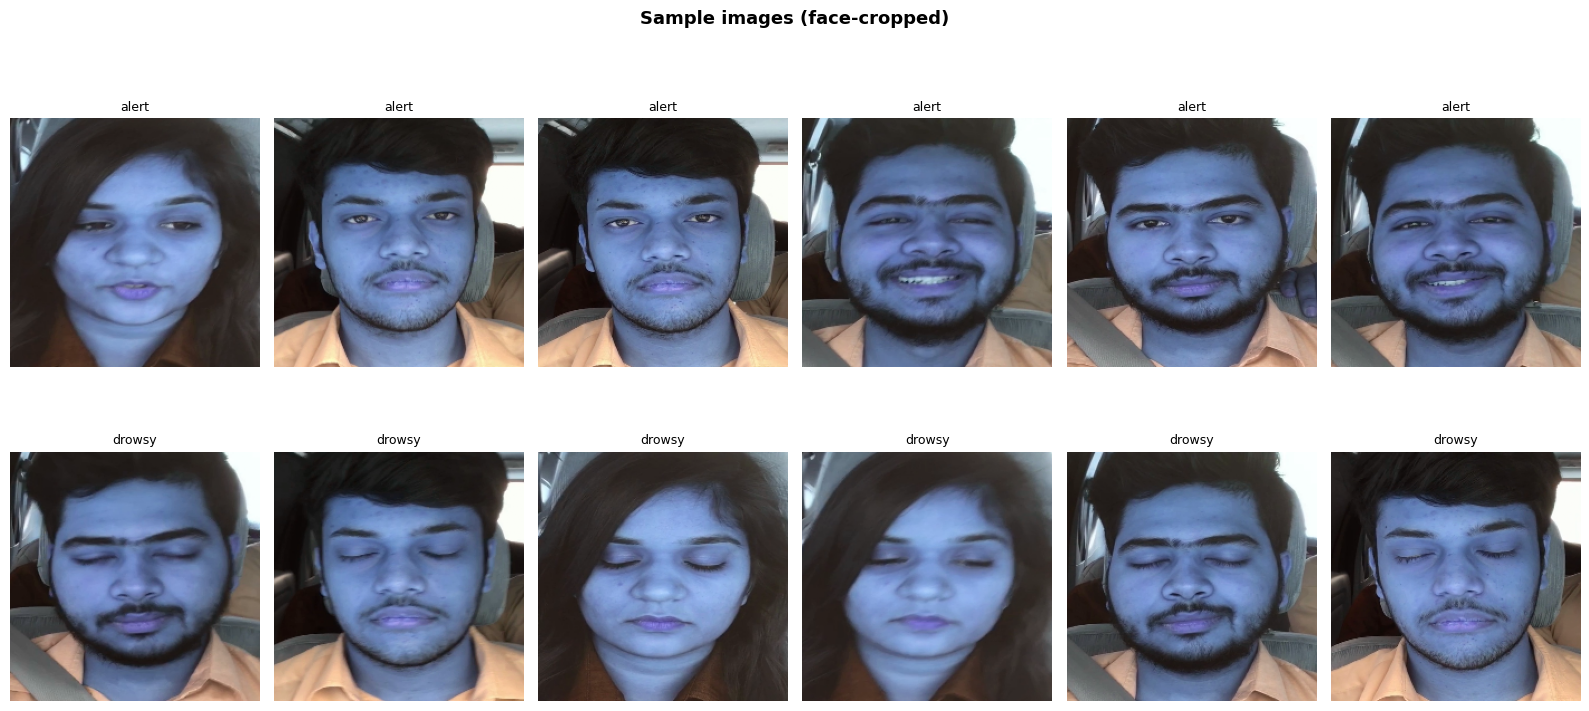

Sample plot saved.


In [35]:
fig, axes = plt.subplots(2, 6, figsize=(16, 8))

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idxs = np.where(y_all == cls_idx)[0]
    sample = np.random.choice(idxs, min(6, len(idxs)), replace=False)

    for col in range(6):
        ax = axes[cls_idx][col]

        if col < len(sample):
            img_idx = sample[col]
            img = X_all[img_idx]

            # Fix negative / wrong colors
            if img.min() < 0:
                img = (img + 1) / 2
            img = np.clip(img, 0, 1)

            ax.imshow(img)
            ax.set_title(cls_name, fontsize=9)

        ax.axis('off')

plt.suptitle('Sample images (face-cropped)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'samples.png', dpi=100)
plt.show()

print('Sample plot saved.')

In [36]:
from sklearn.model_selection import train_test_split

# Stratified 70/10/20 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SPLIT, random_state=SEED, stratify=y_all
)
val_fraction = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train)}  ({Counter(y_train)})')
print(f'Val   : {len(X_val)}   ({Counter(y_val)})')
print(f'Test  : {len(X_test)}  ({Counter(y_test)})')

Train : 923  (Counter({np.int32(1): 550, np.int32(0): 373}))
Val   : 132   (Counter({np.int32(1): 79, np.int32(0): 53}))
Test  : 264  (Counter({np.int32(1): 158, np.int32(0): 106}))


In [37]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in class_weight_dict.items()})

# ── Augmentation (training set only) ───────────────────────────────────────
# MobileNetV2 preprocess_input maps [0,1] → [-1,1]
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,          # valid: faces are symmetric
    rotation_range=10,             # small rotation simulates head tilt
    zoom_range=0.15,               # driver might be at varying distances
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.75, 1.25], # different lighting conditions
    channel_shift_range=20,        # colour temperature variation
)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_test_datagen.flow(X_val,   y_val,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = val_test_datagen.flow(X_test,  y_test,  batch_size=BATCH_SIZE, shuffle=False)

print('Generators ready.')

Class weights: {'alert': np.float64(1.237), 'drowsy': np.float64(0.839)}
Generators ready.


In [38]:
def build_model(num_classes=3, freeze_base=True):
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    base.trainable = not freeze_base

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inputs, training=False)  # BN layers stay in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model, base


model, base_model = build_model(num_classes=len(CLASS_NAMES), freeze_base=True)
model.summary(show_trainable=True)
print(f'Trainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}')

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 1280)          │      5,120 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 1280)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_1       │ (None, 256)           │      1,024 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 2)             │        514 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,592,578 (9.89 MB)

 Trainable params: 331,522 (1.26 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

Trainable params: 331,522


In [39]:
model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        str(OUTPUT_DIR / 'best_phase1.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=0
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
]

print(f'Phase 1: training head for up to {EPOCHS_FROZEN} epochs…')
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)
print('Phase 1 complete.')

Phase 1: training head for up to 10 epochs…
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 813ms/step - accuracy: 0.4919 - loss: 1.0415 - val_accuracy: 0.4015 - val_loss: 1.1829 - learning_rate: 1.0000e-04
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 720ms/step - accuracy: 0.5157 - loss: 1.0646 - val_accuracy: 0.4015 - val_loss: 1.1350 - learning_rate: 1.0000e-04
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 699ms/step - accuracy: 0.5092 - loss: 1.0548 - val_accuracy: 0.4015 - val_loss: 1.1291 - learning_rate: 1.0000e-04
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 694ms/step - accuracy: 0.4789 - loss: 1.0559 - val_accuracy: 0.4015 - val_loss: 1.0799 - learning_rate: 1.0000e-04
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 715ms/step - accuracy: 0.4908 - loss: 1.0315 - val_accuracy: 0.4015 - val_loss: 1.0386 - learning_rate: 1.0000e-04
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 732ms/step - accuracy: 0.5038 - loss: 1.0419 - val_accuracy: 0.4015 - val_loss: 1.0217 - learning_rate: 1.0000e-04
Epoch 6: early

In [40]:
# Unfreeze the last 20 layers of the base model
base_model.trainable = True
fine_tune_at = len(base_model.layers) - 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Phase 2: {trainable_count:,} trainable params (last 20 base layers + head)')

model.compile(
    optimizer=keras.optimizers.Adam(FINE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        str(OUTPUT_DIR / 'best_cnn_model.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1),
]

print(f'Phase 2: fine-tuning for up to {EPOCHS_FINE} epochs…')
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)
print('Phase 2 complete.')

Phase 2: 1,537,602 trainable params (last 20 base layers + head)
Phase 2: fine-tuning for up to 15 epochs…
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.5511 - loss: 1.0770
Epoch 1: val_accuracy improved from None to 0.40152, saving model to cnn_output\best_cnn_model.keras

Epoch 1: finished saving model to cnn_output\best_cnn_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 35s 863ms/step - accuracy: 0.5320 - loss: 1.0731 - val_accuracy: 0.4015 - val_loss: 1.1883 - learning_rate: 1.0000e-05
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.5301 - loss: 1.0559
Epoch 2: val_accuracy did not improve from 0.40152
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 844ms/step - accuracy: 0.5070 - loss: 1.0555 - val_accuracy: 0.4015 - val_loss: 1.2124 - learning_rate: 1.0000e-05
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.4993 - loss: 1.0421
Epoch 3: val_accuracy did not improve from 0.40152
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 800ms/step - accuracy: 0.4735 - loss: 1.11

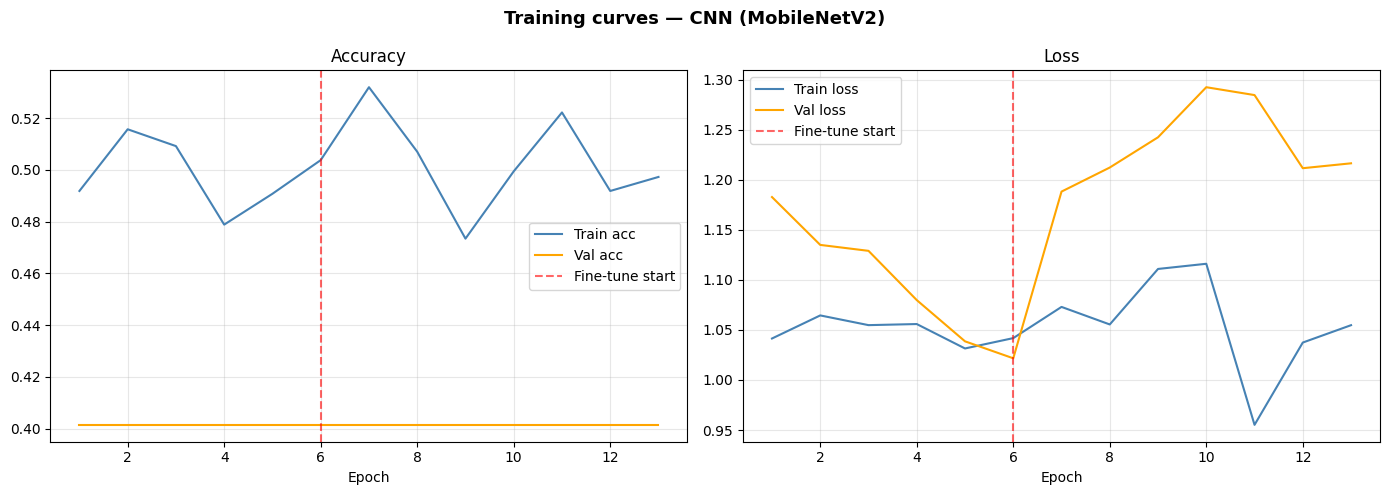

In [41]:
def plot_history(h1, h2):
    # Concatenate both phases
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    val  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']         + h2.history['loss']
    vloss= h1.history['val_loss']     + h2.history['val_loss']
    ep   = range(1, len(acc)+1)
    phase_split = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(ep, acc, label='Train acc', color='steelblue')
    ax1.plot(ep, val, label='Val acc',   color='orange')
    ax1.axvline(phase_split, color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, loss,  label='Train loss', color='steelblue')
    ax2.plot(ep, vloss, label='Val loss',   color='orange')
    ax2.axvline(phase_split, color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('Training curves — CNN (MobileNetV2)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=120)
    plt.show()

plot_history(history1, history2)

              precision    recall  f1-score   support

       alert       0.39      0.57      0.46       106
      drowsy       0.58      0.41      0.48       158

    accuracy                           0.47       264
   macro avg       0.49      0.49      0.47       264
weighted avg       0.50      0.47      0.47       264

F1: 0.47115819503879214
AUC: 0.4891330308096489


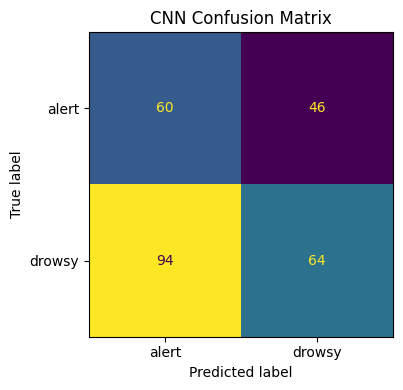

In [48]:
# Load model
best_cnn = keras.models.load_model(OUTPUT_DIR / 'best_cnn_model.keras')

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mp_input

X_test_pp = mp_input(X_test * 255.0)

# Predictions
y_prob_cnn = best_cnn.predict(X_test_pp, batch_size=BATCH_SIZE, verbose=0)

# 🔥 FIX HERE
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

# Metrics
cnn_report = classification_report(y_test, y_pred_cnn, target_names=CLASS_NAMES)
cnn_f1     = f1_score(y_test, y_pred_cnn, average='weighted')
cnn_auc    = roc_auc_score(y_test, y_prob_cnn[:,1])  # for binary

print(cnn_report)
print("F1:", cnn_f1)
print("AUC:", cnn_auc)

# Confusion Matrix
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_cnn, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)

ax.set_title('CNN Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_confusion_matrix.png', dpi=120)
plt.show()

══════════════════════════════════════════════════
GBM (MediaPipe features) TEST RESULTS
══════════════════════════════════════════════════
              precision    recall  f1-score   support

       alert       0.95      0.98      0.96       106
      drowsy       0.99      0.96      0.97       158

    accuracy                           0.97       264
   macro avg       0.97      0.97      0.97       264
weighted avg       0.97      0.97      0.97       264

Weighted F1  : 0.9698
ROC-AUC      : 0.9928


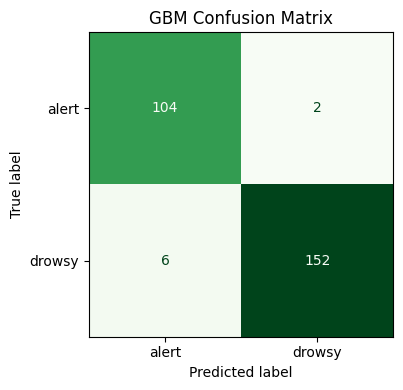

In [42]:
import pandas as pd

FEATURES_CSV = Path('./features.csv')
ALL_FEATURES = ['ear', 'left_ear', 'right_ear', 'mar',
                'head_yaw', 'head_pitch', 'face_width',
                'ear_diff', 'ear_mar_ratio', 'yaw_abs', 'pitch_abs']

if FEATURES_CSV.exists() and GBM_MODEL_PATH.exists():
    gbm_pipeline = joblib.load(GBM_MODEL_PATH)
    df = pd.read_csv(FEATURES_CSV).dropna(subset=ALL_FEATURES + ['label'])

    X_gbm = df[ALL_FEATURES].values
    # GBM is binary: 0=alert, 1=drowsy
    # Map CNN class 2 (yawning) → 1 for GBM comparison
    y_gbm_true = df['label'].values

    _, X_gbm_test, _, y_gbm_test = train_test_split(
        X_gbm, y_gbm_true, test_size=TEST_SPLIT, random_state=SEED, stratify=y_gbm_true
    )

    y_pred_gbm = gbm_pipeline.predict(X_gbm_test)
    y_prob_gbm = gbm_pipeline.predict_proba(X_gbm_test)[:, 1]

    gbm_report = classification_report(y_gbm_test, y_pred_gbm, target_names=['alert', 'drowsy'])
    gbm_f1     = f1_score(y_gbm_test, y_pred_gbm, average='weighted')
    gbm_auc    = roc_auc_score(y_gbm_test, y_prob_gbm)

    print('═'*50)
    print('GBM (MediaPipe features) TEST RESULTS')
    print('═'*50)
    print(gbm_report)
    print(f'Weighted F1  : {gbm_f1:.4f}')
    print(f'ROC-AUC      : {gbm_auc:.4f}')

    cm_gbm = confusion_matrix(y_gbm_test, y_pred_gbm)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm_gbm, display_labels=['alert','drowsy']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title('GBM Confusion Matrix')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'gbm_confusion_matrix.png', dpi=120)
    plt.show()
else:
    print('features.csv or model.pkl not found — skipping GBM evaluation.')
    gbm_f1, gbm_auc = 0.0, 0.0
    gbm_report = 'GBM model not found.'

In [51]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np

# ── Predictions ─────────────────────────────
y_prob_cnn = best_cnn.predict(X_test_pp, batch_size=BATCH_SIZE, verbose=0)

# Binary vs Multi-class handling
if y_prob_cnn.shape[1] == 1:
    # Binary sigmoid output
    y_pred_cnn = (y_prob_cnn > 0.5).astype(int).flatten()
else:
    # Softmax output
    y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

y_true_cnn = y_test

# ── Metrics ─────────────────────────────
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

# ── AUC FIX ─────────────────────────────

if y_prob_cnn.shape[1] == 1:
    # sigmoid case
    cnn_auc = roc_auc_score(y_true_cnn, y_prob_cnn)

elif y_prob_cnn.shape[1] == 2:
    # 🔥 binary softmax → take class 1 prob
    cnn_auc = roc_auc_score(y_true_cnn, y_prob_cnn[:, 1])

else:
    # multi-class (3+ classes)
    cnn_auc = roc_auc_score(y_true_cnn, y_prob_cnn, multi_class='ovr')
print("═"*50)
print("CNN RESULTS")
print("═"*50)
print(classification_report(y_true_cnn, y_pred_cnn))
print(f"F1 Score : {cnn_f1:.4f}")
print(f"AUC      : {cnn_auc:.4f}")

# ── Confusion Matrix ─────────────────────
cm = confusion_matrix(y_true_cnn, y_pred_cnn)
print("Confusion Matrix:\n", cm)

══════════════════════════════════════════════════
CNN RESULTS
══════════════════════════════════════════════════
              precision    recall  f1-score   support

           0       0.39      0.57      0.46       106
           1       0.58      0.41      0.48       158

    accuracy                           0.47       264
   macro avg       0.49      0.49      0.47       264
weighted avg       0.50      0.47      0.47       264

F1 Score : 0.4712
AUC      : 0.4891
Confusion Matrix:
 [[60 46]
 [94 64]]


In [53]:
import json

# ── Decide winner ─────────────────────────
if cnn_f1 >= gbm_f1:
    winner = 'CNN'
else:
    winner = 'GBM'

# ── Save CNN model ────────────────────────
cnn_save_path = OUTPUT_DIR / 'best_cnn_model.keras'
best_cnn.save(cnn_save_path)
print(f'CNN model saved → {cnn_save_path}')

# ── Save metadata ─────────────────────────
metadata = {
    'class_names': CLASS_NAMES,
    'num_classes': len(CLASS_NAMES),
    'img_size': list(IMG_SIZE),
    'use_face_crop': USE_FACE_CROP,
    'winner': winner,
    'cnn_f1': round(cnn_f1, 4),
    'cnn_auc': round(cnn_auc, 4),
    'gbm_f1': round(gbm_f1, 4),
    'gbm_auc': round(gbm_auc, 4),
    'drowsy_threshold': 0.45,
}

meta_path = OUTPUT_DIR / 'cnn_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Metadata saved → {meta_path}')
print('\nContents:', json.dumps(metadata, indent=2))

CNN model saved → cnn_output\best_cnn_model.keras
Metadata saved → cnn_output\cnn_metadata.json

Contents: {
  "class_names": [
    "alert",
    "drowsy"
  ],
  "num_classes": 2,
  "img_size": [
    224,
    224
  ],
  "use_face_crop": true,
  "winner": "GBM",
  "cnn_f1": 0.4712,
  "cnn_auc": 0.4891,
  "gbm_f1": 0.9698,
  "gbm_auc": 0.9928,
  "drowsy_threshold": 0.45
}


True label   : drowsy
Predicted    : drowsy  (confidence: 0.615)
All probs    : {'alert': 0.38538745045661926, 'drowsy': 0.6146125197410583}


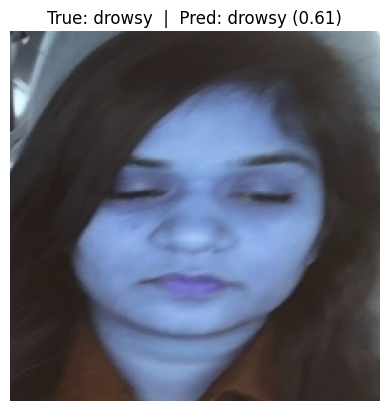

In [55]:
def predict_single_image(img_path_or_array, model, class_names, use_crop=True):
    """
    Accepts a file path (str/Path) or a numpy array (H,W,3) BGR.
    Returns dict with predicted class, confidence, and per-class probabilities.
    """
    from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mp_input

    if isinstance(img_path_or_array, (str, Path)):
        bgr = cv2.imread(str(img_path_or_array))
    else:
        bgr = img_path_or_array

    face = crop_face(bgr) if use_crop else cv2.cvtColor(
        cv2.resize(bgr, IMG_SIZE), cv2.COLOR_BGR2RGB).astype(np.float32)/255

    x = mp_input(np.expand_dims(face * 255.0, axis=0))
    probs = model.predict(x, verbose=0)[0]
    pred_class = int(np.argmax(probs))

    return {
        'class': class_names[pred_class],
        'class_idx': pred_class,
        'confidence': float(probs[pred_class]),
        'probabilities': {cn: float(p) for cn, p in zip(class_names, probs)},
    }


# Test on a random image from the test set
idx = np.random.randint(0, len(X_test))
result = predict_single_image(
    img_path_or_array=(X_test[idx] * 255).astype(np.uint8)[:,:,::-1],  # back to BGR
    model=best_cnn,
    class_names=CLASS_NAMES,
    use_crop=False  # already cropped during loading
)
true_label = CLASS_NAMES[y_test[idx]]
print(f'True label   : {true_label}')
print(f'Predicted    : {result["class"]}  (confidence: {result["confidence"]:.3f})')
print(f'All probs    : {result["probabilities"]}')

plt.imshow(X_test[idx])
plt.title(f'True: {true_label}  |  Pred: {result["class"]} ({result["confidence"]:.2f})')
plt.axis('off')
plt.show()

In [56]:
report_text = f"""DrowseGuard CNN vs GBM Report
{'='*50}
CNN (MobileNetV2)
  Weighted F1 : {cnn_f1:.4f}
  ROC-AUC     : {cnn_auc:.4f}

{cnn_report}

GBM (MediaPipe features)
  Weighted F1 : {gbm_f1:.4f}
  ROC-AUC     : {gbm_auc:.4f}

{gbm_report}

WINNER: {winner}
"""
with open(OUTPUT_DIR / 'comparison_report.txt', 'w') as f:
    f.write(report_text)
print(report_text)
print(f'Report saved → {OUTPUT_DIR}/comparison_report.txt')

DrowseGuard CNN vs GBM Report
CNN (MobileNetV2)
  Weighted F1 : 0.4712
  ROC-AUC     : 0.4891

              precision    recall  f1-score   support

       alert       0.39      0.57      0.46       106
      drowsy       0.58      0.41      0.48       158

    accuracy                           0.47       264
   macro avg       0.49      0.49      0.47       264
weighted avg       0.50      0.47      0.47       264


GBM (MediaPipe features)
  Weighted F1 : 0.9698
  ROC-AUC     : 0.9928

              precision    recall  f1-score   support

       alert       0.95      0.98      0.96       106
      drowsy       0.99      0.96      0.97       158

    accuracy                           0.97       264
   macro avg       0.97      0.97      0.97       264
weighted avg       0.97      0.97      0.97       264


WINNER: GBM

Report saved → cnn_output/comparison_report.txt
